In [1]:
import numpy as np 
import pandas as pd
from tqdm import tqdm
from methyldl.data.soft_labeling import extract_cpg_signature, signature_distance, apply_normalized_knn_smoothing
from EDA.edautils import plot_soft_label_distribution

In [8]:
from torch.nn import Softmax

In [13]:
(np.array([55,59,4]))/sum((np.array([55,49,4])))

array([0.50925926, 0.5462963 , 0.03703704])

In [3]:
np.median([66,58,14])

np.float64(58.0)

In [2]:
import os

In [3]:
data_path = "/home/luna.kuleuven.be/u0169940/Data/Loyfer/SimulatedReads_205files_hg38/all_reads_transformed_uxm_prepared.parquet"

In [4]:
# data_path = '/home/luna.kuleuven.be/u0169940/Data/Loyfer/TrainingDataWithRejection_hg38_mincpg_4_minlen_10/'
# all_data = pd.concat([pd.read_parquet(data_path+f"/{split}.parquet") for split in ["train", "valid", "test"]])

all_data = pd.read_parquet(data_path)

In [5]:
all_data = all_data[all_data["NCPGS"]>=4]

In [6]:
all_data.shape

(4726626, 23)

In [13]:
# Using tqdm for pandas apply (optional, but helpful for large datasets)
tqdm.pandas(desc="Extracting Signatures")
all_data['cpg_sig'] = all_data.progress_apply(extract_cpg_signature, axis=1)

Extracting Signatures:   0%|          | 0/4726626 [00:00<?, ?it/s]

Extracting Signatures: 100%|██████████| 4726626/4726626 [00:38<00:00, 123835.94it/s]


In [14]:
df = all_data.copy()
label_col = "original_label"
num_classes = 39

In [15]:
base_counts = df.groupby(['name', 'cpg_sig', label_col]).size().unstack(fill_value=0)
base_counts = base_counts.reindex(columns=range(num_classes), fill_value=0)
base_counts = base_counts.reset_index()
base_counts["total_reads"] = base_counts[list(range(num_classes))].sum(axis=1)

In [ ]:
mapping_df = apply_normalized_knn_smoothing(base_counts, min_reads=30, num_classes=39,max_distance=0.35,length_penalty_weight=0.1)

Smoothing Regions: 100%|██████████| 844/844 [02:33<00:00,  5.49it/s]


In [67]:
final_data = all_data.merge(mapping_df, on=['name', 'cpg_sig'], how='left')

In [68]:
ctypes = all_data["dmr_ctype"].unique()

In [69]:
ctypes_dict = {key:value for (key,value) in zip(sorted(ctypes), range(len(ctypes)))}

In [70]:
final_data["dmr_ctype_label"] = final_data["dmr_ctype"].apply(lambda x: ctypes_dict[x])

In [ ]:
labels_dict = {x[1]:x[0] for x in final_data[["dmr_ctype", "dmr_ctype_label"]].drop_duplicates().to_dict(orient="split")['data']}

In [72]:
import ast
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
train, valid, test = [pd.read_parquet(new_data_path+x+".parquet") for x in ["train", "valid", "test"]]

Found 18 reads for this subset. Generating plot...


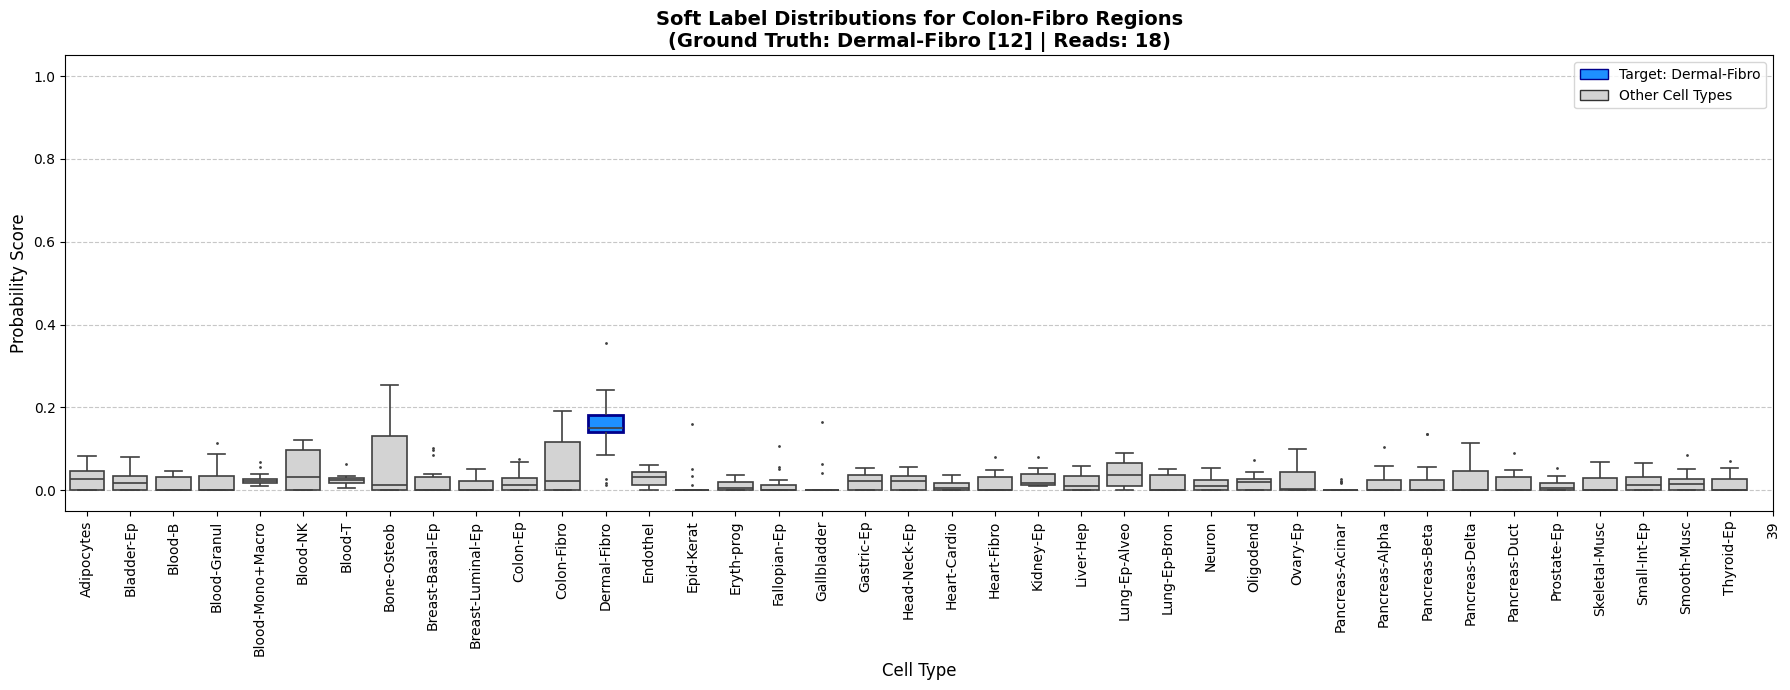

In [18]:
plot_soft_label_distribution(train, target_dmr_ctype="Colon-Fibro", target_label=12,labels_dict=labels_dict)

In [85]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def split_by_file_and_class(df, target_col='original_label', file_col='file', 
                            train_ratio=0.7, valid_ratio=0.15, test_ratio=0.15, 
                            random_state=42):
    """
    Splits the dataset into train, valid, and test sets.
    Prioritizes file-level isolation to prevent data leakage, 
    while EXPLICITLY guaranteeing every class is represented in all splits.
    """
    assert np.isclose(train_ratio + valid_ratio + test_ratio, 1.0), "Ratios must sum to 1.0"
    
    train_chunks, valid_chunks, test_chunks = [], [], []
    
    # Group the entire dataset by the ground truth cell type
    grouped = df.groupby(target_col)
    
    for label, group in grouped:
        # Get read counts per file for this specific cell type
        file_counts = group[file_col].value_counts().to_dict()
        files_sorted = sorted(file_counts.keys(), key=lambda k: file_counts[k], reverse=True)
        n_files = len(files_sorted)
        total_reads = sum(file_counts.values())
        
        if n_files >= 3:
            # REVISED GREEDY FILE-LEVEL ALLOCATION WITH COVERAGE OVERRIDE
            targets = {
                'train': total_reads * train_ratio,
                'valid': total_reads * valid_ratio,
                'test': total_reads * test_ratio
            }
            current_counts = {'train': 0, 'valid': 0, 'test': 0}
            allocations = {'train': [], 'valid': [], 'test': []}
            
            for i, file in enumerate(files_sorted):
                f_count = file_counts[file]
                remaining_files = n_files - i
                
                # Check which buckets still have 0 files
                empty_buckets = [b for b in targets.keys() if not allocations[b]]
                
                # FORCE COVERAGE: If we only have just enough files left to fill the empty 
                # buckets, we must abandon the ratio math and fill the empty buckets.
                if len(empty_buckets) >= remaining_files:
                    best_bucket = max(empty_buckets, key=lambda b: targets[b])
                else:
                    # Otherwise, use standard greedy: give to bucket with highest deficit
                    deficits = {k: targets[k] - current_counts[k] for k in targets}
                    best_bucket = max(deficits, key=deficits.get)
                    
                allocations[best_bucket].append(file)
                current_counts[best_bucket] += f_count
                
            train_chunks.append(group[group[file_col].isin(allocations['train'])])
            valid_chunks.append(group[group[file_col].isin(allocations['valid'])])
            test_chunks.append(group[group[file_col].isin(allocations['test'])])
            
        elif n_files == 2:
            # 2 FILES: Keep Train isolated. Split File 2 into Valid/Test.
            file1, file2 = files_sorted[0], files_sorted[1]
            
            # Put the largest file in Train
            train_chunks.append(group[group[file_col] == file1])
            
            # Split the second file between valid and test
            file2_df = group[group[file_col] == file2]
            val_prop = valid_ratio / (valid_ratio + test_ratio)
            
            val_df, test_df = train_test_split(file2_df, train_size=val_prop, random_state=random_state)
            valid_chunks.append(val_df)
            test_chunks.append(test_df)
            
        else:
            # 1 FILE: Unavoidable read-level split to ensure class coverage.
            file_df = group
            train_df, temp_df = train_test_split(file_df, train_size=train_ratio, random_state=random_state)
            
            val_prop = valid_ratio / (valid_ratio + test_ratio)
            val_df, test_df = train_test_split(temp_df, train_size=val_prop, random_state=random_state)
            
            train_chunks.append(train_df)
            valid_chunks.append(val_df)
            test_chunks.append(test_df)

    # Combine all the chunks
    df_train = pd.concat(train_chunks, ignore_index=True)
    df_valid = pd.concat(valid_chunks, ignore_index=True)
    df_test = pd.concat(test_chunks, ignore_index=True)
    
    return df_train, df_valid, df_test

In [86]:
train_df, valid_df, test_df = split_by_file_and_class(final_data,target_col='original_label')

In [1]:
new_data_path = '/home/luna.kuleuven.be/u0169940/Data/Loyfer/SoftLabelsTrainingData_205files_pooled_hg38_mincpg_4_minlen_10/'

In [9]:
# # os.mkdir(new_data_path)
for name, df in zip(["train", "valid", "test"], [train_df, valid_df, test_df]):
    df.to_parquet(os.path.join(new_data_path, f"{name}.parquet"), index=False)

In [4]:
import pandas as pd

In [5]:
train, valid, test = [pd.read_parquet(new_data_path+x+".parquet") for x in ["train", "valid", "test"]]

In [7]:
x = len(train), len(valid), len(test)

In [8]:
x[0]/sum(x), x[1]/sum(x),x[2]/sum(x)

(0.6156852689423703, 0.19377500991193294, 0.19053972114569673)

In [8]:
train_files = set(train["file"])
valid_files = set(valid["file"])
test_files = set(test["file"])

In [12]:
(valid_files).intersection(test_files)

{'GSM5652199_Colon-Fibroblasts-Z0000042C.hg38_reads.csv',
 'GSM5652204_Dermal-Fibroblasts-Z00000423.hg38_reads.csv',
 'GSM5652205_Skeletal-Muscle-Z00000427.hg38_reads.csv',
 'GSM5652218_Bone-Osteoblasts-Z0000042Z.hg38_reads.csv',
 'GSM5652321_Epidermal-Keratinocytes-Z00000424.hg38_reads.csv',
 'GSM5652358_Gallbladder-Epithelial-Z00000432.hg38_reads.csv'}